# Telco Customer Churn Prediction & Customer Segmentation
**Objective:** Analyze customer data to identify key drivers of churn and build a predictive model to flag high-risk customers before they leave.

### 1. Environment Setup & Data Loading
First, we will import our core data manipulation and visualization libraries, and load the Telco Churn dataset into a Pandas DataFrame.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_excel("../data/Telco_customer_churn.xlsx")

In [2]:
import sys
print(sys.executable)

c:\Users\91749\Documents\CBInternship\ChurnPrediction\venv\Scripts\python.exe


### 2. High-Level Data Inspection
Before analyzing specific features, we need to understand the shape of our data, the data types we are working with, and check for any missing values (NaN) that require cleaning.



In [5]:
df.shape


(7043, 33)

In [ ]:
# Convert Tenure Months from int64 to int8 to save memory 
df['Tenure Months'] = df['Tenure Months'].astype('int8')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int8   
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

**Initial Observations:**
* **Dataset Size:** The dataset contains 7,043 rows (customers) and 33 columns (features).
* **Data Quality:** Fortunately, there are no missing values (`NaN`) in the dataset, meaning we can skip heavy imputation steps.
* **Memory Optimization:** Many numerical columns are currently stored as 64-bit integers (`int64`). For larger pipelines, these could be downcasted to `int8` or `int32` to save memory.

In [8]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int8   
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

### 💡 Engineering Note: Jupyter Display Behavior
In the cell above, we attempted to run three inspection commands at once: `df.info()`, `df.describe()`, and `df.isnull().sum()`. However, the statistical summary table from `df.describe()` did not render on the screen.

**Why did this happen?**
Jupyter Notebooks act like a REPL (Read-Eval-Print Loop) environment. By default, they only automatically render the object returned by the **very last line** of code in a cell. 
* `df.info()` is essentially a `void` function that prints directly to the standard output, which is why it displays at the top.
* `df.describe()` returns a DataFrame object. Because it was on line 2, Jupyter calculated the statistics but threw the object away to move on to line 3.
* `df.isnull().sum()` returns a Series object. Since it was the last line, Jupyter successfully caught it and displayed it.

**The Solution:**
To cleanly display multiple DataFrame objects within a single cell, we must explicitly tell the frontend to render them by wrapping the commands in the `display()` function, or simply split them into individual cells.

```python
# The corrected approach for a single cell:
display(df.info())
display(df.describe())
display(df.isnull().sum())

In [13]:
display(df.info())
display(df.describe())
display(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int8   
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

None

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

### 3. Target Variable Analysis: The Churn Label
Our primary goal is to predict if a customer will churn. Let's look at the distribution of our target variable to see if our dataset is balanced.

In [ ]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


**Business Insight:**
* Out of 7,043 customers, **1,869 (approx. 26.5%)** have churned. 
* **Imbalanced Dataset:** Because the majority of customers (~73%) did not churn, our classes are heavily imbalanced. When building our Machine Learning model later, relying solely on 'Accuracy' will be misleading. We will need to evaluate the model using **Precision, Recall, and F1-Score**.

### 4. Bivariate Analysis: Numerical Features
How do specific numerical features impact a customer's decision to leave? 

**Feature 1: Tenure Months**
Let's visualize the distribution of how long customers stay with the company and how tenure correlates with churn using a histogram and a boxplot.

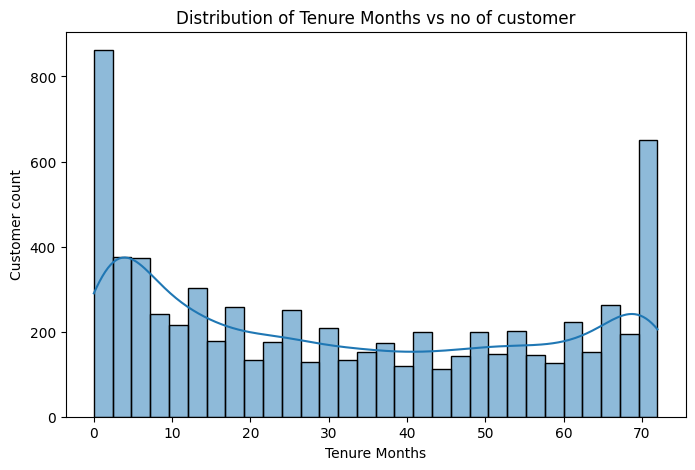

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Tenure Months'],
    bins=30,
    kde=True
)

plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months vs no of customer')

plt.show()

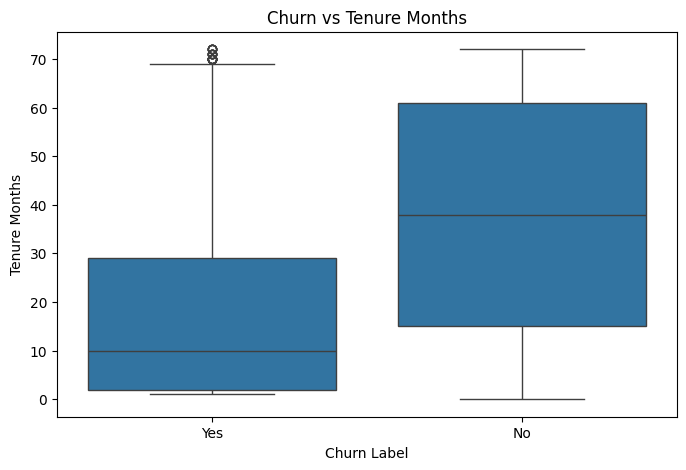

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn Label',
    y='Tenure Months',
    data=df
)

plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Churn vs Tenure Months')

plt.show()

**Business Insight (Tenure):**
* **High Early Attrition:** The boxplot clearly shows that the median tenure for customers who churn is significantly lower than those who stay.
* **Actionable Takeaway:** New customers are at the highest risk of churning within their first few months. The business should implement aggressive onboarding and retention campaigns specifically targeting customers in their first 6 to 12 months.

**Feature 2: Monthly Charges**
Next, let's analyze if the amount a customer pays each month influences their likelihood of churning. We will look at the distributions and calculate the exact quantiles.

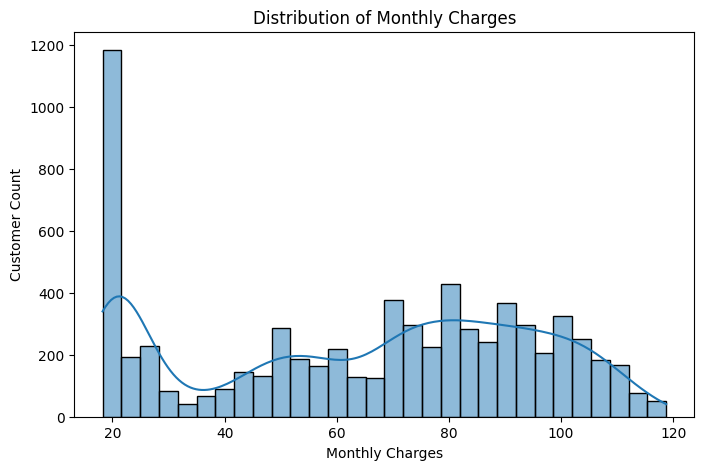

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Monthly Charges'],
    bins=30,
    kde=True
)

plt.xlabel('Monthly Charges')
plt.ylabel('Customer Count')
plt.title('Distribution of Monthly Charges')

plt.show()

In [ ]:
df['Monthly Charges'].max()

118.75

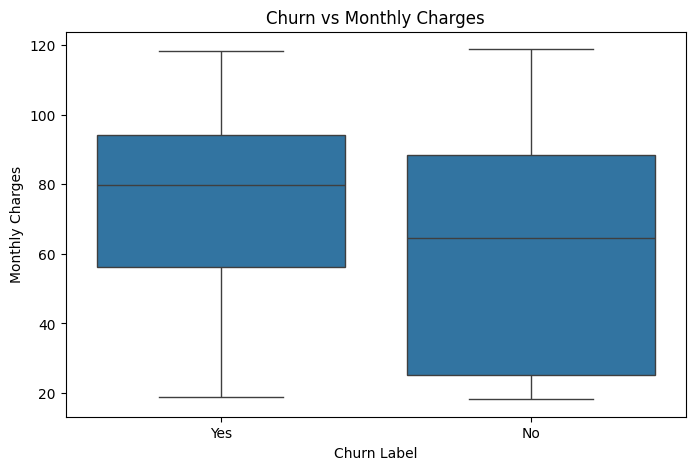

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn Label',
    y='Monthly Charges',
    data=df
)

plt.xlabel('Churn Label')
plt.ylabel('Monthly Charges')
plt.title('Churn vs Monthly Charges')

plt.show()

**Business Insight (Pricing):**
* **Price Sensitivity:** The median monthly charge for a churned customer is **$79.65**, compared to just **$64.42** for a retained customer. 
* **Actionable Takeaway:** Higher monthly bills are strongly associated with churn. Customers paying premium rates are leaving, possibly to cheaper competitors. The company might need to review its pricing strategy for premium tiers or offer loyalty discounts to high-paying users.

### 6. Statistical Validation: Churn vs. Monthly Charges
Visuals are great for finding patterns, but we need hard statistical numbers to back up our insights before presenting them to stakeholders. 

We will use Boolean Indexing to filter our dataset into two distinct groups (Churned vs. Retained) and calculate the 25th, 50th (Median), and 75th percentiles for their Monthly Charges.

*(Note: Data is strictly case-sensitive. Querying 'NO' instead of 'No' will return an empty slice and result in NaN calculations, which highlights the importance of consistent data entry!)*

In [ ]:
df[df['Churn Label']=='Yes']['Monthly Charges']


,Monthly Charges
0,53.85
1,70.70
2,99.65
3,104.80
4,103.70
...,...
1864,59.80
1865,44.20
1866,75.75
1867,102.95


In [ ]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [ ]:
df[df['Churn Label']=='NO']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,NaN
0.50,NaN
0.75,NaN


In [ ]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


**Mathematical Confirmation:**
* **Retained Customers ('No'):** 75% of our loyal customers pay less than **$88.40** per month. Their median bill is **$64.42**.
* **Churned Customers ('Yes'):** 75% of the customers who leave are paying up to **$94.20** per month. Their median bill is **$79.65**.
* **Final Verdict:** The math strictly confirms our earlier boxplot observation. There is a solid ~$15 gap in the median monthly charge between churners and non-churners. High pricing is definitively driving customers away.

### 5. Categorical Analysis
Now we will look at categorical (text) features. What type of contracts do our churned customers hold?

In [12]:
df['Contract'].unique()

<StringArray>
['Month-to-month', 'Two year', 'One year']
Length: 3, dtype: str

In [11]:
df['Contract'].count()

np.int64(7043)

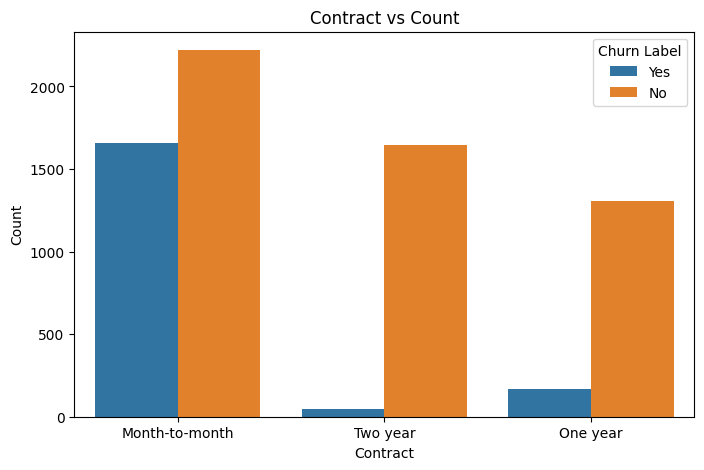

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn Label',
    data=df
)

plt.xlabel('Contract')
plt.ylabel('Count')
plt.title('Contract vs Count')

plt.show()

<Axes: xlabel='Contract', ylabel='count'>

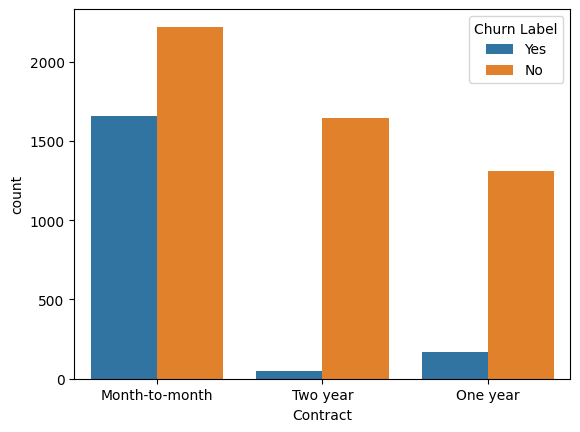

In [4]:
sns.countplot(x='Contract', hue='Churn Label', data=df)

**Business Insight (Contracts):**
* **The Month-to-Month Trap:** There is a massive spike in churn among customers on a "Month-to-month" contract. Customers on One-year or Two-year contracts rarely churn.
* **Actionable Takeaway:** The lack of a lock-in period makes it too easy for month-to-month users to leave. The company should aggressively incentivize users to upgrade to annual contracts (e.g., by offering the first month free on a 1-year plan).

### 9. Categorical Analysis: Internet Service
Does the type of internet connection influence a customer's loyalty? We will visualize the churn distribution across DSL, Fiber Optic, and No Internet Service.

In [14]:
df['Internet Service'].unique()

<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

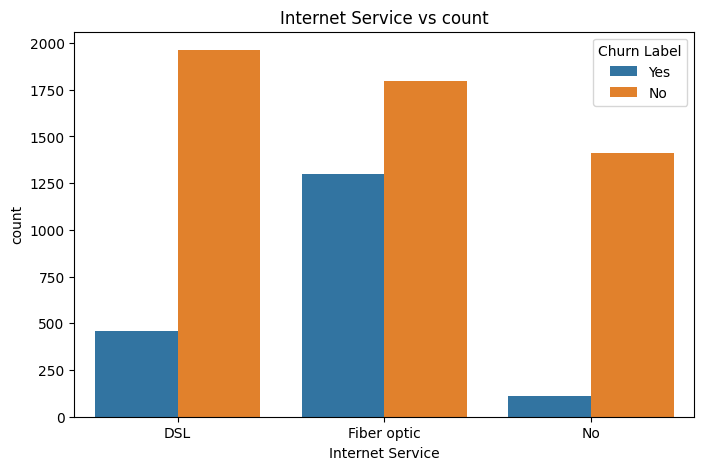

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service', hue='Churn Label', data=df)
plt.xlabel('Internet Service')
plt.ylabel('count')
plt.title('Internet Service vs count')
plt.show()

**Business Insight (Internet Service):**
* **The Fiber Optic Problem:** Customers using Fiber Optic have an unusually high churn rate compared to DSL users. 
* **Why is this happening?** Fiber Optic is typically a premium, high-speed, and high-cost service. If customers are paying top dollar but experiencing network outages, throttling, or bad customer service, they will immediately switch to a competitor. DSL is cheaper and slower, so those customers likely have lower expectations and less incentive to go through the hassle of switching.
* **Actionable Takeaway:** The company needs to urgently investigate the quality and reliability of its Fiber Optic network in high-churn zip codes.

### 10. Categorical Analysis: Payment Method
Next, we examine how the billing friction affects customer retention by plotting Churn against Payment Methods.

In [16]:
df['Payment Method'].unique()

<StringArray>
[             'Mailed check',          'Electronic check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

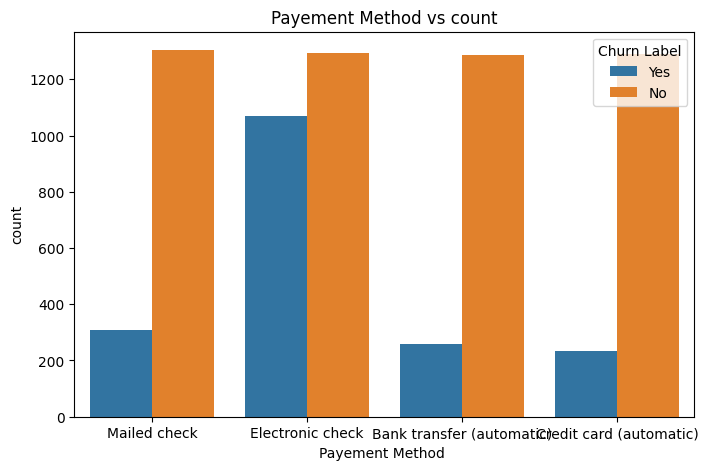

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x='Payment Method', hue='Churn Label', data=df)
plt.xlabel('Payement Method ')
plt.ylabel('count')
plt.title('Payement Method vs count')
plt.show()

**Business Insight (Payment Method):**
* **The Electronic Check Trap:** Customers paying via "Electronic check" account for a massive, disproportionate amount of churn. Customers on automatic payments (Credit Card or Bank Transfer) are highly loyal.
* **Why is this happening?** Automatic payments create psychological "lock-in" (out of sight, out of mind). An electronic check usually requires the customer to manually log in and pay their bill every single month. Every month, they are forced to look at the cost, which triggers the thought: *"Am I paying too much? Should I cancel?"*
* **Actionable Takeaway:** Push all customers toward automatic payment methods. Offer a $5/month discount to anyone who switches their billing from manual checks to auto-pay.

### 11. Categorical Analysis: Tech Support
How does technical assistance impact customer frustration and churn?

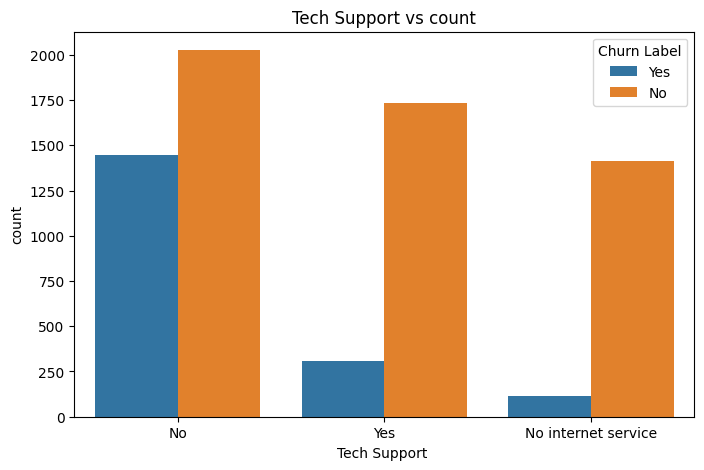

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tech Support', hue='Churn Label', data=df)
plt.xlabel('Tech Support ')
plt.ylabel('count')
plt.title('Tech Support vs count')
plt.show()

**Business Insight (Tech Support):**
* **Frustration Equals Churn:** Customers without Tech Support are churning at an alarming rate, while those with Tech Support are largely retained.
* **Why is this happening?** Internet issues are highly frustrating. If a customer's Wi-Fi goes down and they do not have a dedicated support tier to fix it quickly, they will simply cancel the service out of anger. Having tech support creates a safety net that resolves friction before it turns into a cancellation.
* **Actionable Takeaway:** Tech Support should not be treated as an upsell; it should be heavily subsidized or included in the base package because it acts as a massive churn-prevention tool.

Viewing avg churn months for two groups : SQL aggegrate functions 

In [20]:
avg_tenure = df.groupby("Churn Label")['Tenure Months'].mean()
avg_tenure

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64

### 12. Numerical Correlation & Heatmap
To finalize our Exploratory Data Analysis, we will calculate the exact mean tenure of our customer base and generate a Correlation Heatmap to mathematically prove how our numerical features interact with one another.

In [21]:
numerical_cols = ['Tenure Months','Monthly Charges','Churn Value', 'Churn Score', 'CLTV']
correlation_matrix = df[numerical_cols].corr()
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


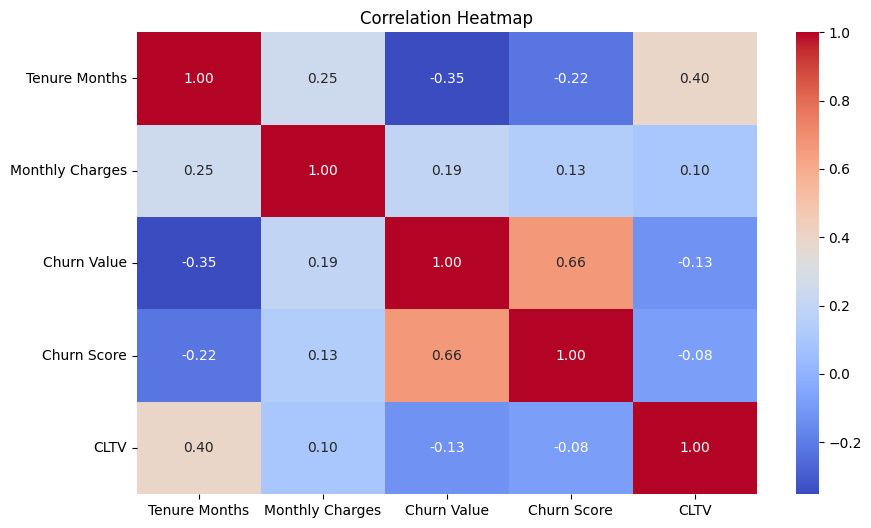

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

**Mathematical Confirmation (Heatmap):**
A correlation score ranges from -1 to 1. A score close to 0 means no relationship. 
* **Tenure vs. Churn Value (-0.35):** There is a solid negative correlation here. As Tenure goes UP, Churn goes DOWN. This confirms our average calculation that loyal customers stay for an average of ~37 months, while churners drop off at just ~18 months.
* **Monthly Charges vs. Churn Value (+0.19):** There is a positive correlation. As the monthly bill goes UP, the likelihood of Churn also goes UP.

### 7. Probability Analysis (Cross-Tabulation)
Our countplot showed a visual spike in churn for month-to-month contracts. To quantify this risk mathematically, we will generate a cross-tabulation table. 

By applying `normalize='index'`, we convert raw customer counts into **churn probabilities** for each contract tier.

In [23]:
pd.crosstab(df['Contract'], df['Churn Label'])

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [24]:
pd.crosstab(df['Contract'], df['Churn Label'], normalize='index')

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


**Actionable Business Insight:**
The normalized contingency table provides exact risk metrics:
* **Critical Risk:** Month-to-month customers have an alarming **42.7% probability** of churning.
* **High Loyalty:** Securing a customer on a two-year contract drops their churn probability to a negligible **2.8%**.
* **Recommendation:** The business should prioritize converting month-to-month users into 1-year or 2-year contracts, potentially by absorbing the cost of the first month to lock them into the lower-risk tiers.

### 8. Data Preprocessing: Type Conversion & Handling Hidden Missing Values
During our initial `df.info()` inspection, the `Total Charges` column was classified as an `object` (string) rather than a numerical `float64`. 

This happens because new customers (Tenure = 0) have their total charges recorded as blank spaces, empty string (`" "`) in the raw data. Machine Learning models require strictly numerical inputs, so we must force this column into a numeric type. 

By using `pd.to_numeric` with `errors='coerce'`, we instruct Pandas to convert the strings to floats and gracefully replace any unparseable blank spaces with standard `NaN` values, which we can then filter or impute.

In [ ]:
df['Total Charges'] =pd.to_numeric(df['Total Charges'],errors="coerce")
print(df['Total Charges'])

0        108.15
1        151.65
2        820.50
3       3046.05
4       5036.30
         ...   
7038    1419.40
7039    1990.50
7040    7362.90
7041     346.45
7042    6844.50
Name: Total Charges, Length: 7043, dtype: float64


In [33]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges          11
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

so we know that churn reason arent missing values, but we cant be sure , either we need to view the whole table to look for non zero values,but the smarter way to do is to use unique function

In [34]:
df.isnull().sum().unique()

array([   0,   11, 5174])

so we see that there are nonzero values =11, so it means these are missing value corresponding to total charges column that we just changed its data type from object to float, so we keep a look out for these kind of strange wierd data types to check for real missing values